In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import random

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,Sequential,Model

import cv2

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:82: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [5]:
# NO CHANGING VARIABLES



In [6]:
# CHANGING VARIABLES




In [7]:
path_of_images = os.path.join("/content/drive/MyDrive/PetImages")
category = os.listdir(path_of_images)

In [8]:
# I READING THE DATA
# the index of cat = 0 ,, Dog = 1

images = []
labels = []
width = 150
hight = 150

for i in category:

  path = os.path.join(path_of_images,i)
  for img in os.listdir(path):
    img_array = cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
    if img_array is not None:
      img_array = cv2.resize(img_array,(width,hight))
      img_array = img_array/255
      if i == "Dog":
        labels.append([i,1])
        images.append([img_array,1])
      elif i == "Cat":
        labels.append([i,0])
        images.append([img_array,0])




In [9]:
test_images = []
train_images = []
cout_cat = 0
cout_dog = 0
cats = 0
dogs = 0
test_size = 0.2

for i in range(len(images)):
  if images[i][1] == 0 :
    cout_cat += 1
  else:
    cout_dog += 1

for i in range(len(images)):
  if len(test_images) <= int(len(images)*test_size):
    if images[i][1] == 0 and cats <= int(cout_cat*test_size):
      test_images.append(images[i])
      images[i] = None
      cats += 1
    elif images[i][1] == 1 and dogs <= int(cout_dog*test_size):
      test_images.append(images[i])
      images[i] = None
      dogs += 1
  else :
    break

for i in range(len(images)):
  if images[0] == None or images[0] == [None]:
    del [images[0]]
  else:
    train_images.append(images[0])
    del [images[0]]


In [10]:
images

[]

In [11]:
print(len(train_images))
print(len(test_images))
print(len(images))

19995
4999
0


In [12]:
random.shuffle(train_images)
random.shuffle(test_images)
labels_train = np.array([ i[1] for i in train_images])
train_images = np.array([ i[0] for i in train_images])
train_images = train_images.reshape(-1,width,hight,1)
labels_test = np.array([ i[1] for i in test_images])
test_images = np.array([ i[0] for i in test_images])
test_images = test_images.reshape(-1,width,hight,1)

In [13]:
print(f"train images shape : {train_images[:2]}")
print(f"train labels shape : {labels_train[:2]}")
print(f"test images shape : {test_images[:2]}")
print(f"test labels shape : {labels_test[:2]}")

train images shape : [[[[0.78431373]
   [0.67843137]
   [0.65882353]
   ...
   [0.30196078]
   [0.29803922]
   [0.27843137]]

  [[0.78039216]
   [0.71764706]
   [0.6627451 ]
   ...
   [0.29803922]
   [0.29411765]
   [0.29019608]]

  [[0.78431373]
   [0.74901961]
   [0.6627451 ]
   ...
   [0.29019608]
   [0.30588235]
   [0.29019608]]

  ...

  [[0.65490196]
   [0.61176471]
   [0.65882353]
   ...
   [0.76078431]
   [0.74509804]
   [0.72941176]]

  [[0.63137255]
   [0.65098039]
   [0.65882353]
   ...
   [0.75686275]
   [0.75294118]
   [0.76078431]]

  [[0.63921569]
   [0.65098039]
   [0.64313725]
   ...
   [0.73333333]
   [0.75294118]
   [0.74901961]]]


 [[[0.34117647]
   [0.36470588]
   [0.35686275]
   ...
   [0.27058824]
   [0.2627451 ]
   [0.2627451 ]]

  [[0.32941176]
   [0.34509804]
   [0.34509804]
   ...
   [0.23137255]
   [0.23529412]
   [0.23529412]]

  [[0.31764706]
   [0.33333333]
   [0.3372549 ]
   ...
   [0.20392157]
   [0.20784314]
   [0.21960784]]

  ...

  [[0.57254902]
  

In [14]:
print(f"train images shape : {train_images.shape}")
print(f"train labels shape : {labels_train.shape}")
print(f"test images shape : {test_images.shape}")
print(f"test labels shape : {labels_test.shape}")

train images shape : (19995, 150, 150, 1)
train labels shape : (19995,)
test images shape : (4999, 150, 150, 1)
test labels shape : (4999,)


In [15]:
# np.save("train_images.npy",train_images)
# np.save("train_labels.npy",labels_train)
# np.save("test_images.npy",test_images)
# np.save("test_labels.npy",labels_test)

In [16]:
# train_images = np.load("train_images.npy")
# labels_train = np.load("train_labels.npy")
# test_images = np.load("test_images.npy")
# labels_test = np.load("test_labels.npy")

In [17]:
model = Sequential([

    # layers.Conv2D(128,(3,3), padding='same', activation='relu', input_shape=(width,hight,1)),
    # layers.MaxPool2D(pool_size=(2, 2),strides=(1,1),padding='same'),
    # layers.Conv2D(100,(3,3), padding='same', activation='relu'),
    # layers.MaxPool2D(pool_size=(2, 2),strides=(1,1),padding='same'),
    # layers.Conv2D(50,(3,3), padding='same', activation='relu'),
    # layers.MaxPool2D(pool_size=(2, 2),strides=(1,1),padding='same'),
    # # layers.Conv2D(77,(3,3), padding='same', activation='relu'),
    # # layers.MaxPool2D(pool_size=(2, 2),strides=(1,1),padding='same'),
    # layers.Flatten(),
    # layers.Dense(100,activation="sigmoid"),
    # layers.Dense(182,activation="sigmoid"),
    # layers.Dense(280,activation="sigmoid"), # i add this
    # layers.Dense(50,activation="sigmoid"),
    # layers.Dense(2,activation="softmax")




    layers.Conv2D(32,(3,3), padding='same', activation='relu', input_shape=(width,hight,1)),
    layers.MaxPool2D(pool_size=(2, 2),padding='same'),
    layers.Conv2D(32,(3,3), padding='same', activation='relu'),
    layers.MaxPool2D(pool_size=(2, 2),padding='same'),
    layers.Conv2D(32,(3,3), padding='same', activation='relu'),
    layers.MaxPool2D(pool_size=(2, 2),padding='same'),
    # layers.Conv2D(20,(3,3), padding='same', activation='relu'),
    # layers.MaxPool2D(pool_size=(2, 2),strides=(1,1),padding='same'),
    layers.Flatten(),
    layers.Dense(35,activation="sigmoid"),
    layers.Dense(40,activation="sigmoid"),
    layers.Dense(32,activation="sigmoid"), # i add this
    layers.Dense(40,activation="sigmoid"),
    layers.Dense(2,activation="softmax")

])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(optimizer ="adam",loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [19]:
model.fit(train_images,labels_train,
                         validation_data=(test_images,labels_test),
                         epochs=12,
                         batch_size=300,
                         verbose=1,
                         validation_split=0.2,
                         validation_batch_size=100,
                         shuffle=True,
                         callbacks=[tf.keras.callbacks.EarlyStopping(
                                            patience=6,
                                            monitor='val_accuracy',#"val_loss",
                                            restore_best_weights=True)])




# x=None,
#     y=None,
#     batch_size=None,
#     epochs=1,
#     verbose='auto',
#     callbacks=None,
#     validation_split=0.0,
#     validation_data=None,
#     shuffle=True,
#     class_weight=None,
#     sample_weight=None,
#     initial_epoch=0,
#     steps_per_epoch=None,
#     validation_steps=None,
#     validation_batch_size=None,
#     validation_freq=1

Epoch 1/12
67/67 ━━━━━━━━━━━━━━━━━━━━ 63s 922ms/step - accuracy: 0.4987 - loss: 0.6945 - val_accuracy: 0.6117 - val_loss: 0.6849
Epoch 2/12
67/67 ━━━━━━━━━━━━━━━━━━━━ 63s 945ms/step - accuracy: 0.6195 - loss: 0.6712 - val_accuracy: 0.6683 - val_loss: 0.6168
Epoch 3/12
67/67 ━━━━━━━━━━━━━━━━━━━━ 58s 866ms/step - accuracy: 0.6852 - loss: 0.5970 - val_accuracy: 0.7319 - val_loss: 0.5421
Epoch 4/12
67/67 ━━━━━━━━━━━━━━━━━━━━ 66s 978ms/step - accuracy: 0.7336 - loss: 0.5367 - val_accuracy: 0.7471 - val_loss: 0.5154
Epoch 5/12
67/67 ━━━━━━━━━━━━━━━━━━━━ 66s 982ms/step - accuracy: 0.7549 - loss: 0.5078 - val_accuracy: 0.7532 - val_loss: 0.5089
Epoch 6/12
67/67 ━━━━━━━━━━━━━━━━━━━━ 67s 995ms/step - accuracy: 0.7704 - loss: 0.4746 - val_accuracy: 0.7544 - val_loss: 0.5073
Epoch 7/12
67/67 ━━━━━━━━━━━━━━━━━━━━ 66s 983ms/step - accuracy: 0.7915 - loss: 0.4449 - val_accuracy: 0.7680 - val_loss: 0.4791
Epoch 8/12
67/67 ━━━━━━━━━━━━━━━━━━━━ 67s 992ms/step - accuracy: 0.8120 - loss: 0.4123 - val_accu

In [20]:
model.evaluate(test_images,labels_test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8188 - loss: 0.4247


[0.42930811643600464, 0.8155631422996521]

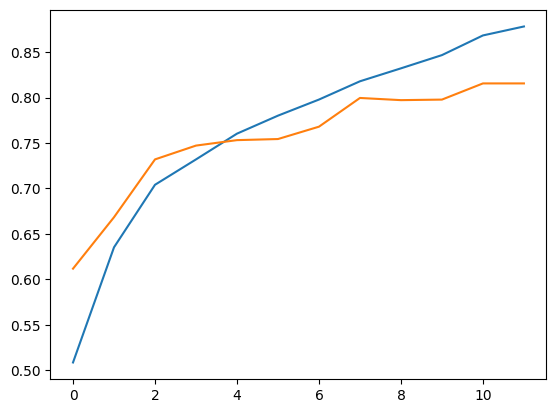

In [21]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])

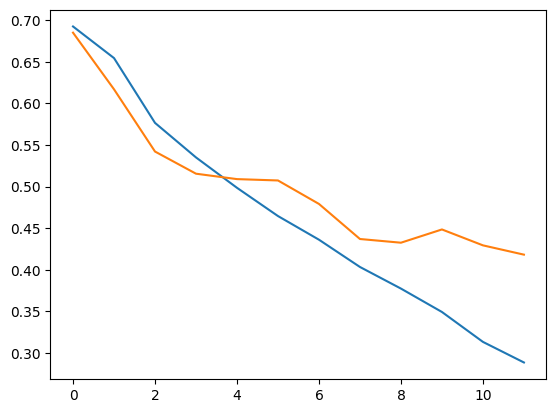

In [22]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])